In [174]:
import pandas as pd
import os

df = pd.read_csv(r"D:\student-exam-score-prediction-ml\dataset\student_habits_performance.csv")

In [175]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [177]:
df.shape

(1000, 16)

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [179]:
sns.set_style('whitegrid')

In [180]:
df.isna().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [181]:
df = df.dropna()

In [182]:
df

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [183]:
df.duplicated().sum()

np.int64(0)

In [184]:
import warnings
warnings.filterwarnings('ignore')

In [185]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000,909.000000
mean,20.475248,3.538724,2.504620,1.830363,83.880308,6.474037,3.051705,5.466447,69.558196
std,2.302721,1.469730,1.164802,1.071251,9.453622,1.218943,2.035632,2.857525,16.929436
min,17.000000,0.000000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.000000,2.500000,1.700000,1.000000,77.500000,5.600000,1.000000,3.000000,58.400000
50%,20.000000,3.500000,2.500000,1.800000,84.200000,6.500000,3.000000,5.000000,70.400000
75%,22.000000,4.500000,3.300000,2.600000,90.700000,7.300000,5.000000,8.000000,81.300000
max,24.000000,8.300000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [186]:
df.describe(include='object').columns

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')

In [187]:
categorical_cols = ["gender", "part_time_job", "diet_quality", "parental_education_level", "internet_quality", "extracurricular_participation"]

In [188]:
for col in categorical_cols:
    print(f"Value counts for {col}: \n{df[col].value_counts()}")

Value counts for gender: 
gender
Male      440
Female    433
Other      36
Name: count, dtype: int64
Value counts for part_time_job: 
part_time_job
No     713
Yes    196
Name: count, dtype: int64
Value counts for diet_quality: 
diet_quality
Fair    396
Good    347
Poor    166
Name: count, dtype: int64
Value counts for parental_education_level: 
parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
Value counts for internet_quality: 
internet_quality
Good       410
Average    352
Poor       147
Name: count, dtype: int64
Value counts for extracurricular_participation: 
extracurricular_participation
No     620
Yes    289
Name: count, dtype: int64


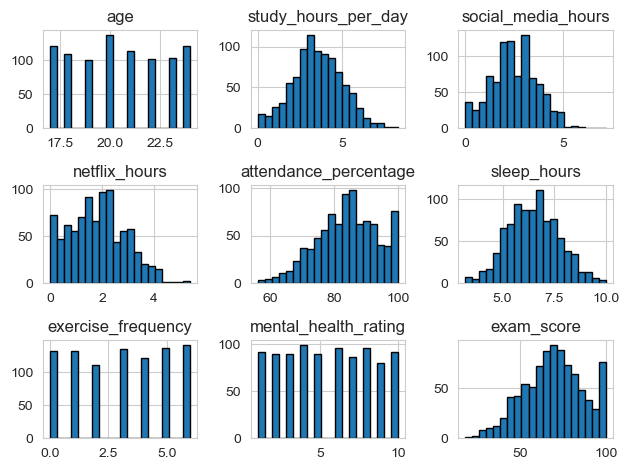

In [189]:
df.hist(bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

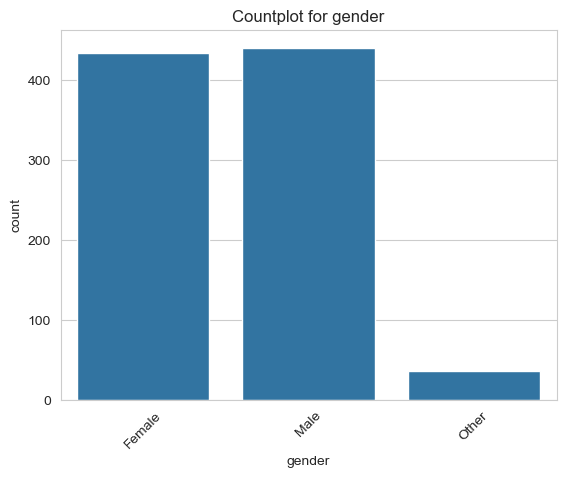

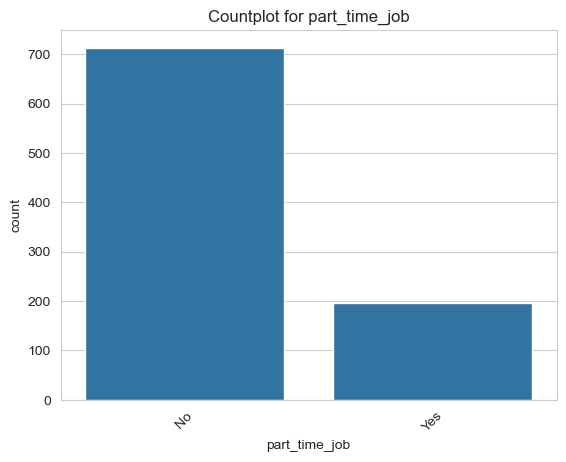

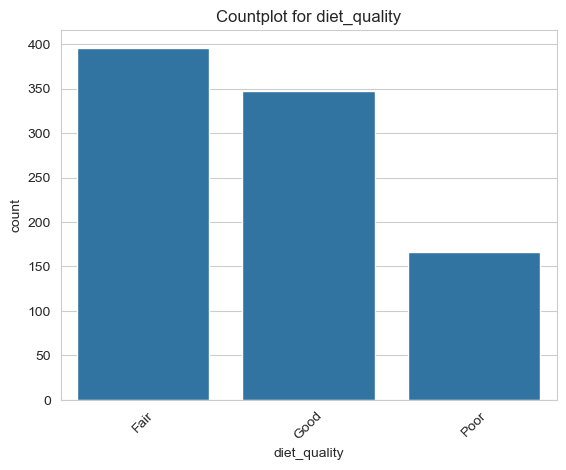

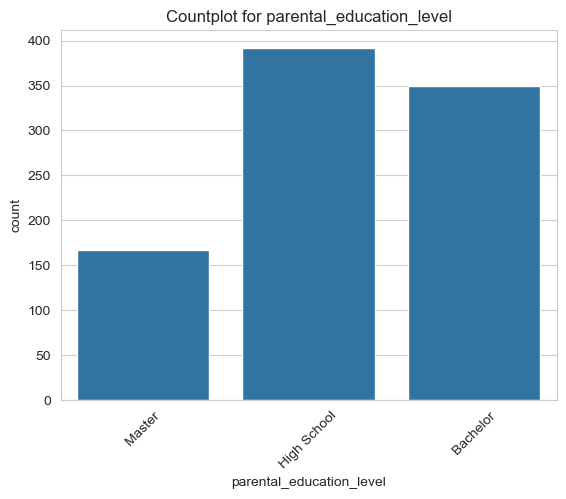

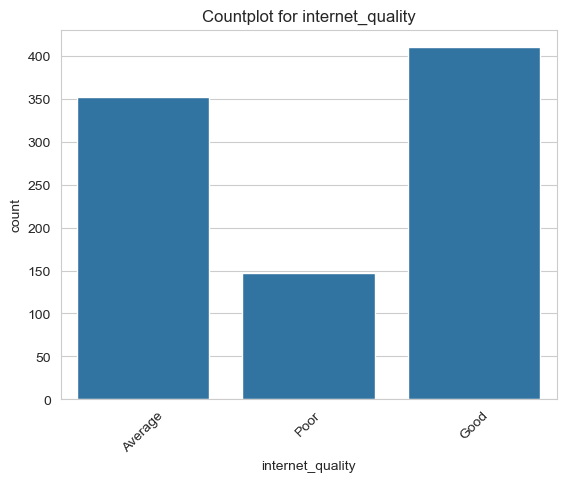

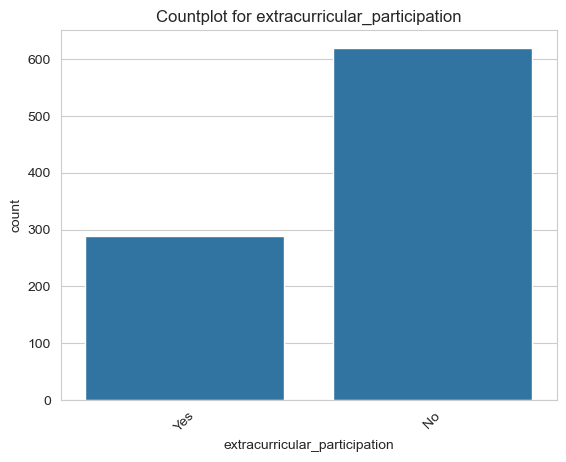

In [190]:
for col in categorical_cols:
    sns.countplot(x=col, data=df)
    plt.title(f"Countplot for {col}")
    plt.xticks(rotation=45)
    plt.show()

In [191]:
df.corr(numeric_only=True)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
age,1.000000,0.007150,-0.023854,0.005841,-0.030203,0.040498,-0.005718,-0.052137,-0.012833
study_hours_per_day,0.007150,1.000000,0.007364,-0.014493,0.028967,-0.026241,-0.024708,-0.015896,0.822950
social_media_hours,-0.023854,0.007364,1.000000,0.011865,0.049356,0.026861,-0.023975,-0.000417,-0.171672
netflix_hours,0.005841,-0.014493,0.011865,1.000000,-0.015008,-0.017006,-0.004155,-0.016612,-0.166578
attendance_percentage,-0.030203,0.028967,0.049356,-0.015008,1.000000,0.001972,-0.010563,-0.017096,0.096005
sleep_hours,0.040498,-0.026241,0.026861,-0.017006,0.001972,1.000000,0.030013,-0.010653,0.122294
exercise_frequency,-0.005718,-0.024708,-0.023975,-0.004155,-0.010563,0.030013,1.000000,-0.001500,0.161397
mental_health_rating,-0.052137,-0.015896,-0.000417,-0.016612,-0.017096,-0.010653,-0.001500,1.000000,0.317945
exam_score,-0.012833,0.822950,-0.171672,-0.166578,0.096005,0.122294,0.161397,0.317945,1.000000


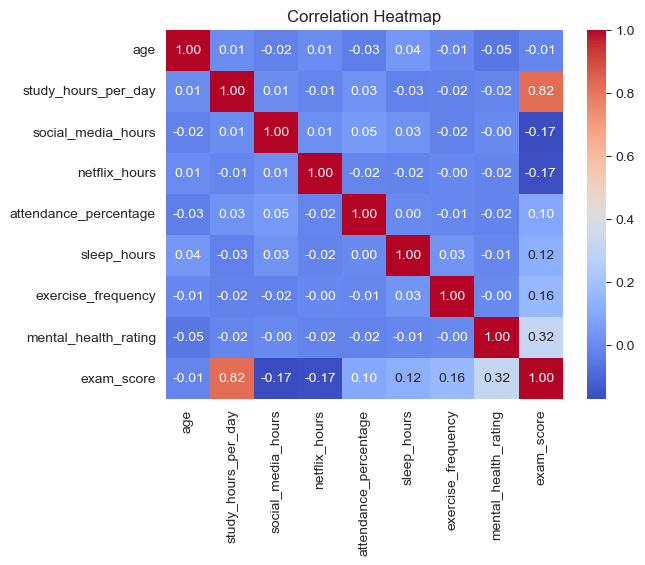

In [192]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [193]:
df.describe().columns

Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

In [194]:
num_features = ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating']

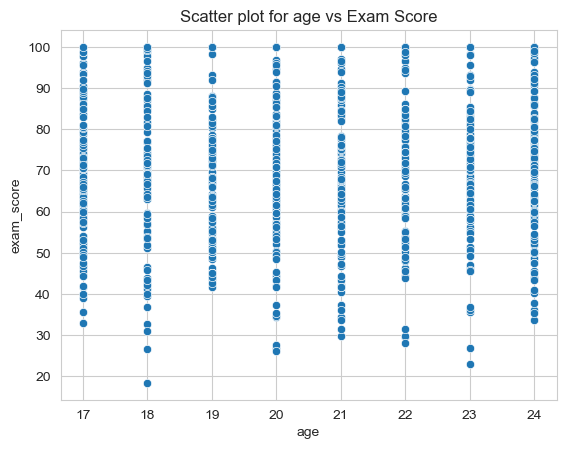

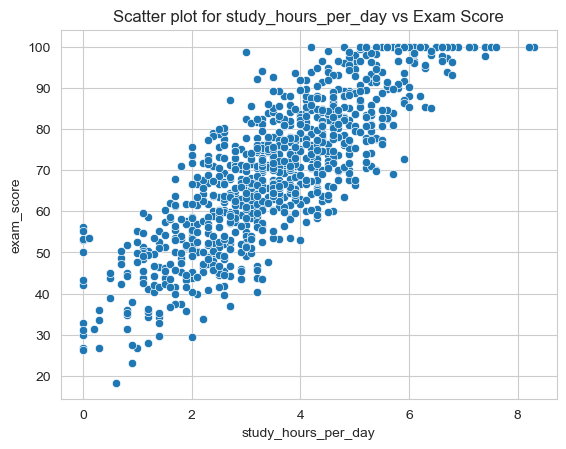

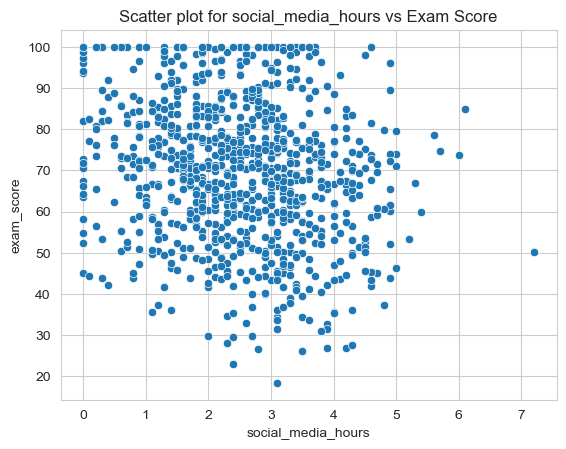

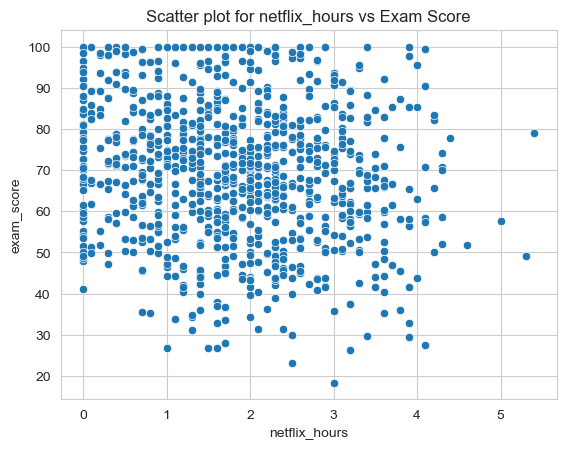

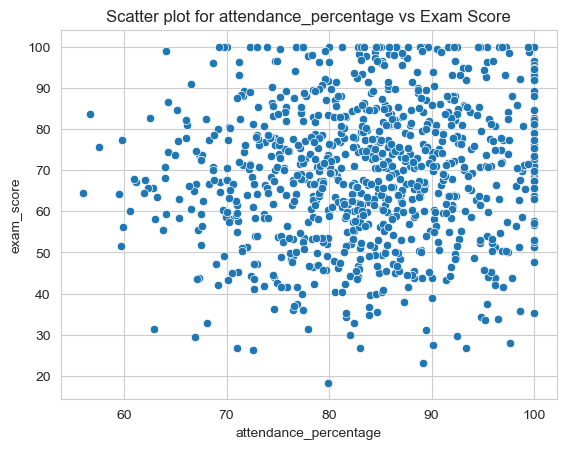

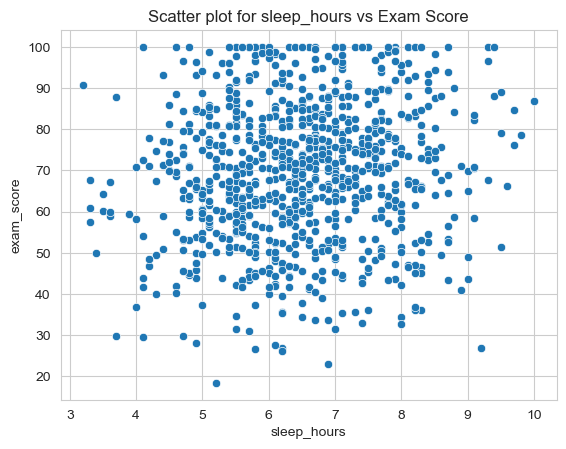

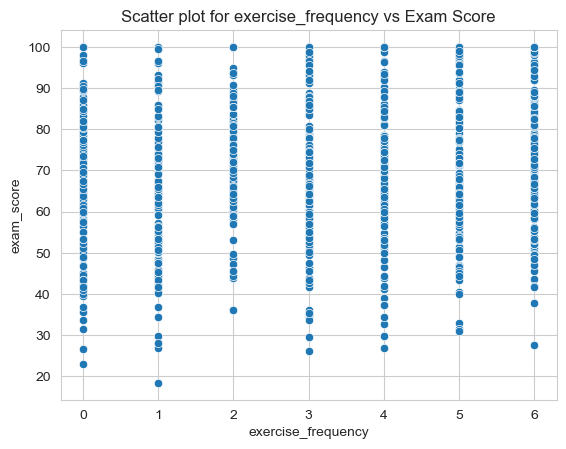

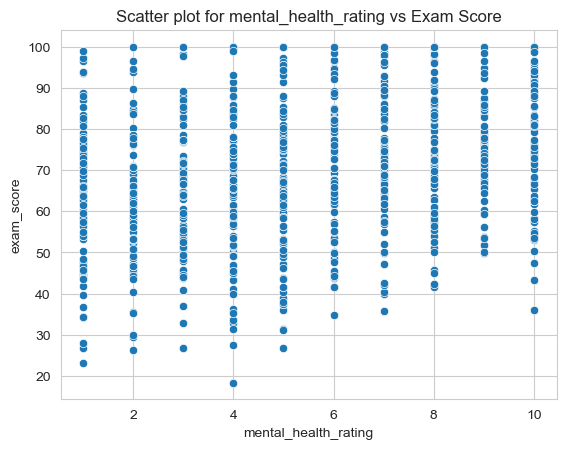

In [195]:
for feature in num_features:
    sns.scatterplot(data=df, x=feature, y='exam_score')
    plt.title(f"Scatter plot for {feature} vs Exam Score")
    plt.show()

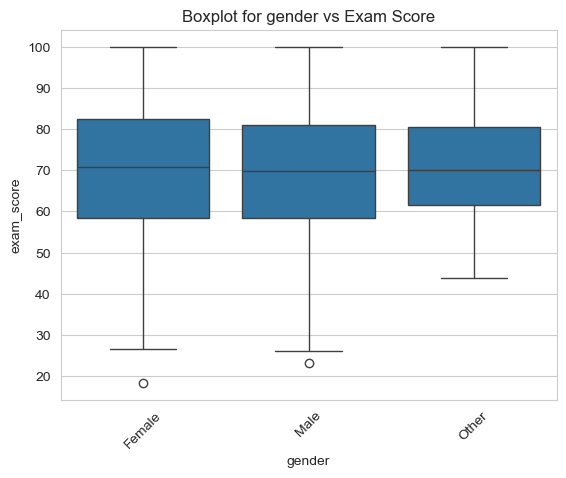

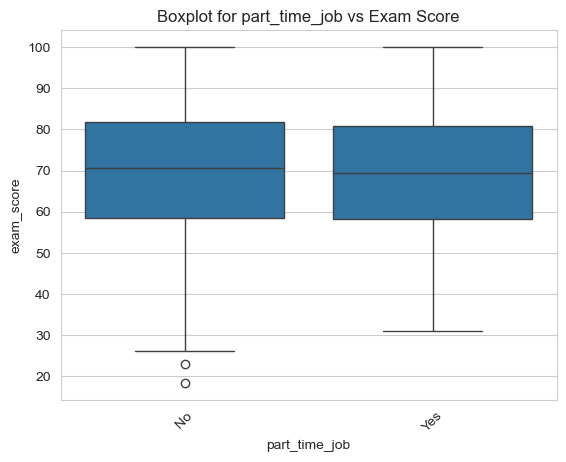

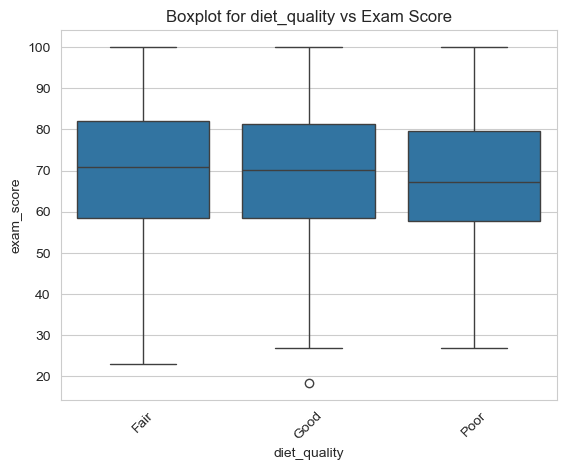

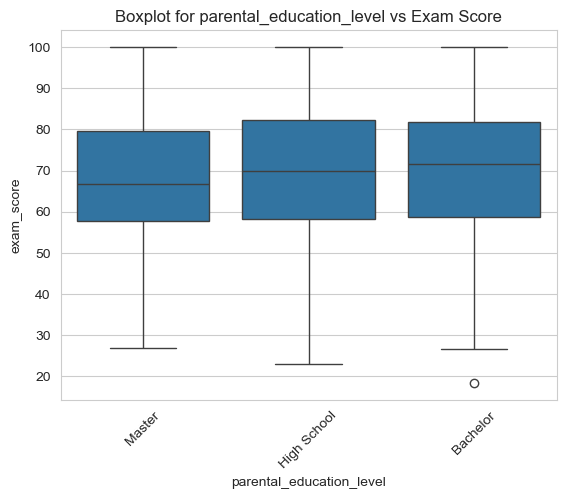

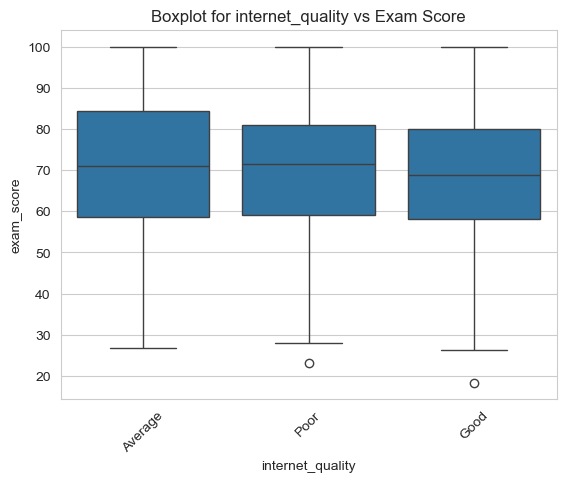

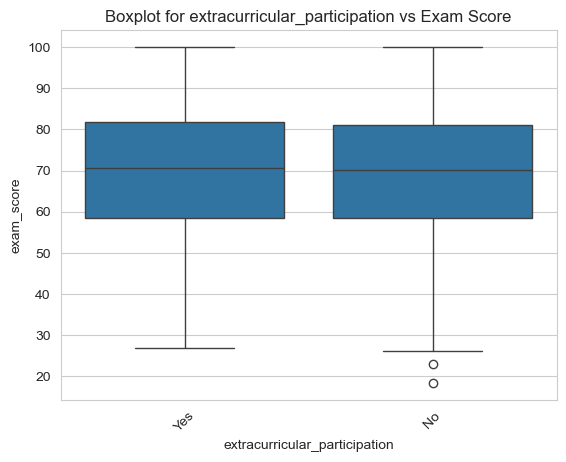

In [196]:
for col in categorical_cols:
    sns.boxplot(x=col, y='exam_score', data=df)
    plt.title(f"Boxplot for {col} vs Exam Score")
    plt.xticks(rotation=45)
    plt.show()

In [197]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [198]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [199]:
features = ['study_hours_per_day', 'attendance_percentage', 'mental_health_rating', 'sleep_hours', 'part_time_job']

In [200]:
target = 'exam_score'

In [201]:
df_model = df[features + [target]].copy()

In [202]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,No,56.2
1,6.9,97.3,8,4.6,No,100.0
2,1.4,94.8,1,8.0,No,34.3
3,1.0,71.0,1,9.2,No,26.8
4,5.0,90.9,1,4.9,No,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,No,76.1
996,2.9,86.0,6,6.8,Yes,65.9
997,3.0,61.9,9,6.5,No,64.4
998,5.4,100.0,1,7.6,Yes,69.7


In [203]:
le = LabelEncoder()

In [204]:
df_model['part_time_job'] = le.fit_transform(df_model['part_time_job'])

In [205]:
df_model

,study_hours_per_day,attendance_percentage,mental_health_rating,sleep_hours,part_time_job,exam_score
0,0.0,85.0,8,8.0,0,56.2
1,6.9,97.3,8,4.6,0,100.0
2,1.4,94.8,1,8.0,0,34.3
3,1.0,71.0,1,9.2,0,26.8
4,5.0,90.9,1,4.9,0,66.4
...,...,...,...,...,...,...
995,2.6,77.0,6,7.5,0,76.1
996,2.9,86.0,6,6.8,1,65.9
997,3.0,61.9,9,6.5,0,64.4
998,5.4,100.0,1,7.6,1,69.7


In [206]:
x = df_model[features]

In [207]:
y = df_model[target]

In [208]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [209]:
len(y_train), len(y_test)

(727, 182)

In [210]:
models = {
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {}
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(),
        "params": {
            'max_depth': [3, 5,10], 'min_samples_split': [2, 5]
        }
    },
    "Random Forest": {
        "model": RandomForestRegressor(),
        "params": {
            'n_estimators': [50, 100], 'max_depth': [5, 10]
        }
    },
}

In [211]:
best_models = []

In [212]:
for name, config in models.items():
    print(f"Training {name}...")
    
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='neg_mean_squared_error')
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    best_models.append({
        "model_name": name,
        "best_params": grid.best_params_,
        "rmse": rmse,
        "r2": r2
    })

Training Linear Regression...
Training Decision Tree...
Training Random Forest...


In [213]:
best_models

[{'model_name': 'Linear Regression',
  'best_params': {},
  'rmse': np.float64(7.548988055242228),
  'r2': 0.8092372564061352},
 {'model_name': 'Decision Tree',
  'best_params': {'max_depth': 5, 'min_samples_split': 2},
  'rmse': np.float64(8.75409855991842),
  'r2': 0.7434695356013441},
 {'model_name': 'Random Forest',
  'best_params': {'max_depth': 5, 'n_estimators': 100},
  'rmse': np.float64(7.860274079626398),
  'r2': 0.793180509951737}]

In [214]:
results_df = pd.DataFrame(best_models)

In [215]:
results_df.sort_values(by='rmse') 

,model_name,best_params,rmse,r2
0,Linear Regression,{},7.548988,0.809237
2,Random Forest,"{'max_depth': 5, 'n_estimators': 100}",7.860274,0.793181
1,Decision Tree,"{'max_depth': 5, 'min_samples_split': 2}",8.754099,0.743470


In [216]:
import joblib

best_row = results_df.sort_values(by='rmse').iloc[0]

In [217]:
best_row

model_name     Linear Regression
best_params                   {}
rmse                    7.548988
r2                      0.809237
Name: 0, dtype: object

In [218]:
best_model_name = best_row['model_name']

In [219]:
best_model_name

'Linear Regression'

In [220]:
best_model_config = models[best_model_name]

In [221]:
best_model_config

{'model': LinearRegression(), 'params': {}}

In [222]:
final_model = best_model_config['model']

In [224]:
final_model.fit(x, y)

LinearRegression()

In [225]:
final_model.predict(X_test)

array([ 92.71797491,  68.22890505,  56.46241714,  70.5947591 ,
        68.26348682,  90.10938622,  83.76282292,  56.50647088,
        80.61992577,  64.38337437,  52.07971586,  74.59529628,
        64.94639018,  54.77872093,  85.31042026,  66.70036983,
        65.13307337,  59.88818359,  85.2652158 ,  60.05075545,
        92.44727813,  51.42035996,  78.93841603,  80.07009373,
        69.35389946,  73.59376451,  56.51857377,  68.00488232,
        88.8343056 ,  72.64278476,  61.2642645 ,  87.76819727,
        70.1122084 ,  62.07233324,  81.43685695,  60.61304698,
        75.00352966,  69.99857536,  59.33617791,  77.67278715,
        56.52867139,  78.89418139,  50.87089394,  45.97432955,
        70.22148331,  68.15955942,  82.25691263,  59.04507085,
        83.96961185,  51.88362859,  79.94294863,  71.09065397,
        90.35284716,  69.96011467,  71.89251839,  71.42430502,
        65.33003352,  62.84795641,  48.17243843,  42.46689961,
        80.04701348,  48.67726609,  69.19275373,  74.07

In [226]:
joblib.dump(final_model, 'final_model.pkl')

['final_model.pkl']

In [227]:
joblib.load("final_model.pkl").predict(X_test)

array([ 92.71797491,  68.22890505,  56.46241714,  70.5947591 ,
        68.26348682,  90.10938622,  83.76282292,  56.50647088,
        80.61992577,  64.38337437,  52.07971586,  74.59529628,
        64.94639018,  54.77872093,  85.31042026,  66.70036983,
        65.13307337,  59.88818359,  85.2652158 ,  60.05075545,
        92.44727813,  51.42035996,  78.93841603,  80.07009373,
        69.35389946,  73.59376451,  56.51857377,  68.00488232,
        88.8343056 ,  72.64278476,  61.2642645 ,  87.76819727,
        70.1122084 ,  62.07233324,  81.43685695,  60.61304698,
        75.00352966,  69.99857536,  59.33617791,  77.67278715,
        56.52867139,  78.89418139,  50.87089394,  45.97432955,
        70.22148331,  68.15955942,  82.25691263,  59.04507085,
        83.96961185,  51.88362859,  79.94294863,  71.09065397,
        90.35284716,  69.96011467,  71.89251839,  71.42430502,
        65.33003352,  62.84795641,  48.17243843,  42.46689961,
        80.04701348,  48.67726609,  69.19275373,  74.07